In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0,'../g3algo/')
import iterativecombination as ic
from scipy.optimize import curve_fit

In [14]:
df = pd.read_csv("ECOdata_G3catalog_luminosity.csv")

In [15]:
df=df[(df.absrmag<-17.33)&(df.g3grpcz_l>3000)&(df.g3grpcz_l<7000)]
grpdf = df.groupby('g3grp_l').first()
giantonly = df.groupby('g3grp_l').filter(lambda grp: (grp.absrmag<=-19.5).any())
giantonly = giantonly[(giantonly.absrmag<=-19.5)]

In [16]:
giantonly.loc[:,'giantgrpabsrmag']=ic.get_int_mag(giantonly.absrmag.to_numpy(),giantonly.g3grp_l.to_numpy())

In [17]:
giantonly=giantonly.groupby('g3grp_l').first()

# Calibration Idea 1 (in addition to normal L,r_tot calibration for giants+dwarfs)

idea 1; additional calibration would be: HAM mass derived using integrated luminosity of giants+dwarf group vs. M_r,tot just for giants.

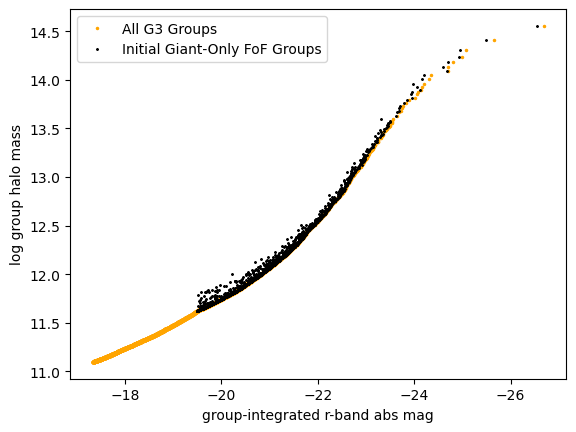

In [27]:
%matplotlib inline
plt.figure()
plt.plot(grpdf.g3grpabsrmag_l,grpdf.g3logmh_l,'.',markersize=3,color='orange',label='All G3 Groups')
plt.plot(giantonly.giantgrpabsrmag,giantonly.g3logmh_l,marker='D',ls='None',markersize=1,\
        markeredgecolor='k',markerfacecolor='None',label='Initial Giant-Only FoF Groups')
plt.gca().invert_xaxis()
plt.ylabel("log group halo mass")
plt.xlabel("group-integrated r-band abs mag")
plt.legend(loc='best')
plt.show()

In [102]:
from scipy.interpolate import UnivariateSpline, CubicSpline

<IPython.core.display.Javascript object>


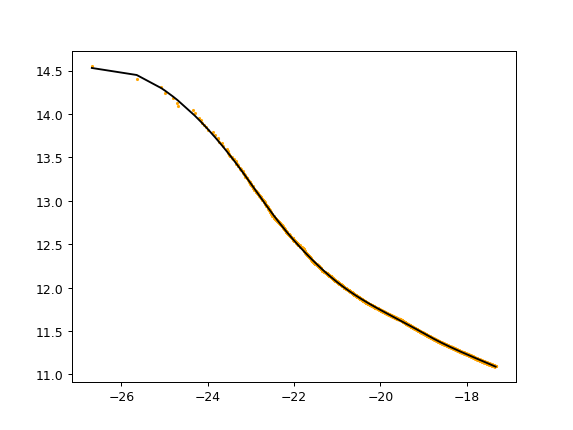

-0.000309978668581401
0.0019223218363482175
[14.53063992 14.59093523 14.06193234 13.00642658 12.67571604 12.34740807
 11.99458886 11.75922321 11.57399654 11.31919724 11.19448222 11.08977555]
[-26.68640299 -23.15373165 -22.75783034 -22.29021973 -21.68650532
 -20.9853     -19.9819     -19.2756     -18.7777     -17.3304    ]


AttributeError: 'UnivariateSpline' object has no attribute 'c'

In [112]:
def sigline(x,A1,A,B,C,D):
    return 1/(1+A*np.exp(-B*(x+26)))**A1 + C*x + D

%matplotlib notebook
plt.figure()
plt.plot(grpdf.g3grpabsrmag_l,grpdf.g3logmh_l,'.',markersize=3,color='orange',label='All G3 Groups')

xx = grpdf.g3grpabsrmag_l.to_numpy()
yy = grpdf.g3logmh_l.to_numpy()
xx = np.sort(xx)
yy = -1*np.sort(-yy)

spl = UnivariateSpline(xx,yy,s=0.1) #s=0.1 Univ
plt.plot(xx,spl(xx),'k-')
print(np.median(yy-spl(xx)))
print(np.median(np.abs(yy-spl(xx))))
print(spl.get_coeffs())
print(spl.get_knots())
print(spl.c[3,0])

# print(popt)
# popt,pcov = curve_fit(sigline,xx,yy)#p0=[2,1,1,0.2,12])
# plt.plot(xx,sigline(xx,*popt))

plt.gca().invert_xaxis()
plt.ylabel("log group halo mass")
plt.xlabel("group-integrated r-band abs mag")
plt.legend(loc='best')
plt.show()

# Calibration Idea 1 (in addition to normal L,r_tot calibration for giants+dwarfs)

idea 2; additional calibration would be: HAM mass derived using integrated luminosity of giant-only groups vs. M_r,tot just for giants. So the HAM would be performed only for giant-only groups.

In [6]:
df = pd.read_csv("ECOdata_G3catalog_luminosity.csv")

In [7]:
df=df[(df.absrmag<-17.33)&(df.g3grpcz_l>3000)&(df.g3grpcz_l<7000)]
grpdf = df.groupby('g3grp_l').first()
giantonly = df.groupby('g3grp_l').filter(lambda grp: (grp.absrmag<=-19.5).any())
giantonly = giantonly[(giantonly.absrmag<=-19.5)]

In [8]:
giantonly.loc[:,'giantgrpabsrmag']=ic.get_int_mag(giantonly.absrmag.to_numpy(),giantonly.g3grp_l.to_numpy())

In [9]:
haloid,halologmass,_,_=ic.HAMwrapper(giantonly.radeg,giantonly.dedeg,giantonly.cz,giantonly.absrmag,giantonly.g3grp_l,volume=192351.)

In [10]:
giantonlygroupmass=np.zeros(len(giantonly))
grpid = giantonly.g3grp_l.to_numpy()
for ii,hh in enumerate(haloid):
    sel = np.where(grpid==hh)
    giantonlygroupmass[sel]=halologmass[ii]
giantonlygroupmass = giantonlygroupmass - np.log10(0.7) # convert to h=0.7
giantonly.loc[:,'giantlogmh']=giantonlygroupmass

In [11]:
giantonly=giantonly.groupby('g3grp_l').first()

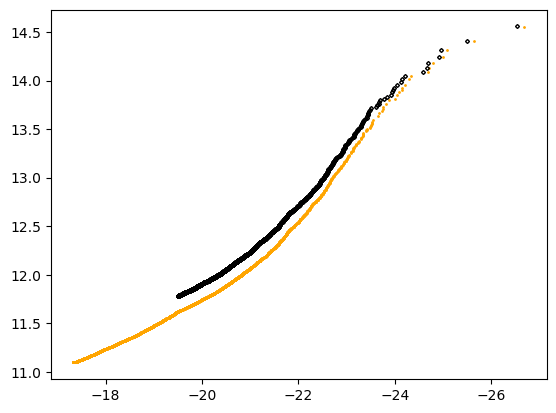

In [12]:
%matplotlib inline
plt.figure()
plt.plot(grpdf.g3grpabsrmag_l,grpdf.g3logmh_l,'.',markersize=2,color='orange')
plt.plot(giantonly.giantgrpabsrmag,giantonly.giantlogmh,marker='D',ls='None',markersize=2,\
        markeredgecolor='k',markerfacecolor='None')
plt.gca().invert_xaxis()
plt.show()

Are HAM masses the same using both approaches with HAM?

In [29]:
for gg in giantonly.index.to_numpy():
    val1 = np.mean(giantonly.giantlogmh[giantonly.index==gg])
    val2 = np.mean(grpdf.g3logmh_l[grpdf.index==gg])
    print(val1, val2)

12.629901959985743 12.452901959985743
13.258901959985742 13.122901959985745
12.801901959985743 12.668901959985742
12.476901959985742 12.299901959985744
14.048901959985743 14.047901959985744
12.833901959985743 12.691901959985744
11.822901959985742 11.816901959985744
11.799901959985743 11.639901959985744
13.122901959985743 13.040901959985742
11.971901959985743 11.809901959985742
11.792901959985743 11.634901959985744
12.451901959985744 12.343901959985743
14.556901959985742 14.555901959985745
11.888901959985743 11.727901959985743
12.910901959985743 12.771901959985744
12.281901959985744 12.197901959985742
12.534901959985744 12.350901959985745
12.017901959985743 11.853901959985745
11.922901959985744 11.758901959985742
11.976901959985742 11.813901959985744
11.984901959985743 11.821901959985745
11.892901959985743 11.730901959985744
11.790901959985742 11.632901959985745
12.101901959985742 11.932901959985744
12.639901959985743 12.490901959985743
12.891901959985743 12.753901959985743
12.269901959

KeyboardInterrupt: 